# **IMPLEMENTACIÓN DE UN ALGORITMO GENÉTICO PARALELO CON DASK**

Este notebook implementa el mismo algoritmo genético del notebook `02_genetic_algorithm.ipynb`, con el mismo dataset y los mismos parámetros. La única diferencia está en la función de aptitud: en lugar de entrenar los 100 árboles de decisión de cada generación uno tras otro, los distribuimos entre varios procesos (workers) con Dask para entrenarlos en paralelo.

> **Nota:** recomendamos ejecutar este notebook en hardware local. Las instancias estándar de Google Colab ofrecen solo 2 vCPU, que normalmente corresponden a un único núcleo físico, y eso se vuelve un cuello de botella: Dask no tiene suficientes núcleos para repartir los entrenamientos y el costo de coordinar las tareas termina siendo mayor que el tiempo que se gana en paralelo.

In [1]:
import os
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

from dask.distributed import Client, LocalCluster
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo

## **CLÚSTER LOCAL DE DASK**

Creamos un clúster local con un worker por cada núcleo del procesador. Cada worker es un proceso independiente con un solo hilo, así cada uno entrena un árbol a la vez sin competir con los demás por el mismo núcleo.

In [2]:
cluster = LocalCluster(
    n_workers=os.cpu_count(),
    threads_per_worker=1,
    processes=True
)
client = Client(cluster)

print(f'Workers: {len(client.scheduler_info()["workers"])}')
client

Workers: 8


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 8,Total memory: 15.54 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41595,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36699,Total threads: 1
Dashboard: http://127.0.0.1:42005/status,Memory: 1.94 GiB
Nanny: tcp://127.0.0.1:35061,


## **CARGA DE DATOS**

Cargamos el mismo dataset que en el notebook secuencial y eliminamos los registros duplicados.

In [3]:
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 

In [4]:
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

df = pd.concat([X, y], axis=1)

In [5]:
# df = df.drop_duplicates()

df.shape

(253680, 22)

In [6]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X.shape

(253680, 21)

Enviamos `X` e `y` a todos los workers una sola vez con `scatter`. Si los pasáramos directamente en cada tarea, Dask tendría que copiar el dataset completo a los workers 100 veces por generación.

In [7]:
X_dask = client.scatter(X, broadcast=True)
y_dask = client.scatter(y, broadcast=True)

## **ETAPA #1: Inicializamos la población**

Igual que en el notebook secuencial: un gen por cada una de las 21 variables de `X`.

In [8]:
def initialize_poblation(size=100):
    random_seed = 42
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    rng = np.random.default_rng(random_seed)
    poblacion = rng.integers(0, 2, size=(size, 21))
    poblacion = pd.DataFrame(poblacion)
    
    poblacion["F1"] = 0
    return poblacion

## **ETAPA #2: Función de Aptitud (FITNESS) en paralelo**

Separamos el entrenamiento de un individuo en la función `entrenar_individuo`, que es la tarea que ejecuta cada worker. La función `fitness` envía los 100 individuos al clúster con `client.map`, espera los resultados con `client.gather` y los guarda en la columna `F1`, en el mismo orden de los individuos.

El scheduler de Dask se ejecuta en segundo plano dentro de este mismo proceso y usa el módulo `random` internamente. Eso altera los números aleatorios del cruce y la mutación, así que las poblaciones no coinciden exactamente con las del notebook secuencial. Aun así, ambas versiones entrenan la misma cantidad de modelos por generación, por lo que la comparación de tiempos es válida.

In [9]:
def entrenar_individuo(genes: np.ndarray, X: pd.DataFrame, Y: pd.Series):
    folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    modelo = DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    )

    # Genes en 1 = variables seleccionadas
    columnas = X.columns[genes.astype(bool)].tolist()

    # Sin variables no se puede entrenar el modelo
    if not columnas:
        return 0.0

    return cross_val_score(modelo, X[columnas], Y, cv=folds, scoring='f1').mean()


def fitness(individuos: pd.DataFrame, X, Y):
    individuos = individuos.drop('F1', axis=1)

    # Cada individuo es una tarea que Dask envía a un worker libre
    tareas = client.map(entrenar_individuo, list(individuos.to_numpy()), X=X, Y=Y)
    resultados_f1 = client.gather(tareas)

    individuos['F1'] = resultados_f1

    return individuos

## **ETAPA #3: SELECCIÓN**

Igual que en el notebook secuencial.

In [10]:
def best_50(poblacion: pd.DataFrame):
    ordered_poblation = poblacion.sort_values(by="F1", ascending=False)
    top50 = ordered_poblation.head(50)
    return top50

## **ETAPA #4: CRUCE**

Igual que en el notebook secuencial.

In [11]:
def crossing(individuos: pd.DataFrame, gamma: float = 0.5):
    padres = individuos.drop('F1', axis=1)
    hijos = padres.to_numpy().copy()

    for i in range(0, len(hijos) - 1, 2):
        for j in range(hijos.shape[1]):
            # Con probabilidad gamma, los dos hijos intercambian este gen
            if random.random() <= gamma:
                hijos[i, j], hijos[i + 1, j] = hijos[i + 1, j], hijos[i, j]

    hijos = pd.DataFrame(hijos, columns=padres.columns)

    # La nueva población está formada por los 50 padres y sus 50 hijos
    nueva_poblacion = pd.concat([padres, hijos], ignore_index=True)
    nueva_poblacion['F1'] = 0

    return nueva_poblacion

## **ETAPA #5: MUTACIÓN**

Igual que en el notebook secuencial.

In [12]:
def mutation(poblacion: pd.DataFrame, prob_mutacion: float = 0.05):
    genes = poblacion.drop('F1', axis=1).to_numpy().copy()

    for i in range(genes.shape[0]):
        for j in range(genes.shape[1]):
            # El gen cambia de 0 a 1 o de 1 a 0
            if random.random() <= prob_mutacion:
                genes[i, j] = 1 - genes[i, j]

    poblacion = pd.DataFrame(genes)
    poblacion['F1'] = 0
    return poblacion

## **ETAPA #6: IMPLEMENTACIÓN**

La función `genetic_algorithm` es la misma del notebook secuencial; solo cambia que muestra el progreso cada 2 generaciones (`reportar_cada`), aunque el historial guarda todas. Al ejecutarla le pasamos `X_dask` e `Y_dask`, así la función `fitness` usa los datos que ya están en los workers.

In [13]:
def genetic_algorithm(generations: int, X: pd.DataFrame, Y: pd.Series, population_size: int = 100, reportar_cada: int = 2):
    poblacion = initialize_poblation(size=population_size)
    poblacion = fitness(
        individuos=poblacion, 
        X=X, 
        Y=Y
    )
    
    historial = []

    for i in range(generations):
        top50 = best_50(poblacion=poblacion)

        new_generation = crossing(
            individuos=top50
        )
        
        new_generation = mutation(
            poblacion=new_generation
        )
        
        poblacion = fitness(
            individuos=new_generation, 
            X=X, 
            Y=Y
        )

        historial.append({
            'generacion': i + 1,
            'mejor_F1': poblacion['F1'].max(),
            'F1_promedio': poblacion['F1'].mean()
        })

        # Mostramos el progreso cada `reportar_cada` generaciones
        if (i + 1) % reportar_cada == 0:
            print(f"[INFO] Generación {i + 1}: mejor F1 = {poblacion['F1'].max():.4f}")

    mejor_individuo = poblacion.sort_values(by='F1', ascending=False).iloc[0]

    return mejor_individuo, pd.DataFrame(historial)

## **EJECUCIÓN**

Ejecutamos el algoritmo genético con Dask durante 100 generaciones y medimos su tiempo de ejecución para compararlo con la versión secuencial.

In [14]:
inicio = time.perf_counter()

mejor_individuo, historial = genetic_algorithm(generations=10, X=X_dask, Y=y_dask)

tiempo_dask = time.perf_counter() - inicio
print(f'Tiempo de ejecución: {tiempo_dask:.1f} segundos')

[INFO] Generación 2: mejor F1 = 0.4258
[INFO] Generación 4: mejor F1 = 0.4258
[INFO] Generación 6: mejor F1 = 0.4260
[INFO] Generación 8: mejor F1 = 0.4260
[INFO] Generación 10: mejor F1 = 0.4260
Tiempo de ejecución: 635.6 segundos


## **RESULTADOS**

Variables seleccionadas por el mejor individuo y evolución del F1 en cada generación.

In [15]:
genes = mejor_individuo.drop('F1').values.astype(bool)
variables_seleccionadas = X.columns[genes].tolist()

print(f"F1 del mejor individuo: {mejor_individuo['F1']:.4f}")
print(f'Variables seleccionadas: {len(variables_seleccionadas)} de {X.shape[1]}')

variables_seleccionadas

F1 del mejor individuo: 0.4260
Variables seleccionadas: 12 de 21


['HighBP',
 'HighChol',
 'BMI',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'Sex',
 'Education']

In [16]:
historial

,generacion,mejor_F1,F1_promedio
0,1,0.426012,0.403412
1,2,0.425768,0.406694
2,3,0.425768,0.414579
3,4,0.425768,0.417174
4,5,0.425768,0.414879
5,6,0.426012,0.421102
6,7,0.426012,0.418903
7,8,0.426012,0.418756
8,9,0.426012,0.420024
9,10,0.426012,0.422127


## **COMPARACIÓN CON LA VERSIÓN SECUENCIAL**

Leemos el tiempo que guardó el notebook `02_genetic_algorithm.ipynb` (antes hay que ejecutar ahí la celda que lo guarda) y lo comparamos con el de esta ejecución.

Como las dos versiones pueden ejecutarse con distinto número de generaciones, comparamos el **tiempo promedio por generación**: en ambas, la población inicial y cada generación entrenan 100 modelos. Una aceleración mayor que 1 indica que Dask fue más rápido. La gráfica se guarda en `outputs/ga_secuencial_vs_dask.png`.

Aceleración de Dask: ×1.56


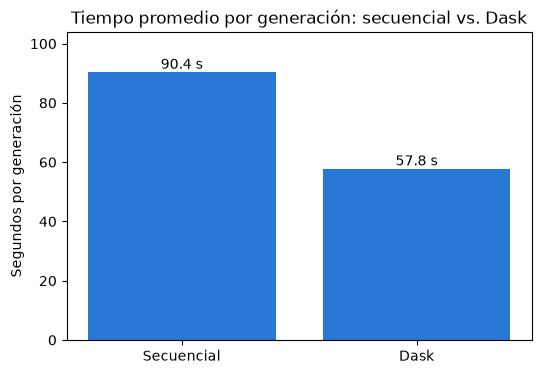

In [19]:
tiempos = pd.read_csv('../outputs/tiempo_secuencial.csv')
tiempos.loc[len(tiempos)] = ['Dask', len(historial), tiempo_dask]

# La población inicial y cada generación entrenan 100 modelos en ambas versiones
tiempos['tiempo_por_generacion_s'] = tiempos['tiempo_s'] / (tiempos['generaciones'] + 1)

aceleracion = tiempos.loc[0, 'tiempo_por_generacion_s'] / tiempos.loc[1, 'tiempo_por_generacion_s']
print(f'Aceleración de Dask: ×{aceleracion:.2f}')

plt.figure(figsize=(6, 4))
barras = plt.bar(tiempos['version'], tiempos['tiempo_por_generacion_s'], color='#2a78d6')
plt.bar_label(barras, fmt='%.1f s')

plt.title('Tiempo promedio por generación: secuencial vs. Dask')
plt.ylabel('Segundos por generación')
plt.ylim(0, tiempos['tiempo_por_generacion_s'].max() * 1.15)

plt.savefig('../outputs/ga_secuencial_vs_dask.png')
plt.show()

Cerramos el clúster para liberar los procesos.

In [18]:
client.close()
cluster.close()

2026-09-16 13:01:08,879 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-09-16 13:01:08,882 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-09-16 13:01:08,884 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-09-16 13:01:08,889 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-09-16 13:01:08,896 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-09-16 13:01:08,901 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-09-16 13:01:08,904 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-09-16 13:01:08,906 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing


## **CONCLUSIONES**

Ejecutamos las dos versiones del algoritmo en dos equipos:

- **Google Colab (2 vCPU):** con 10 generaciones, la versión secuencial tardó 674.8 s y la versión con Dask (2 workers) 715.6 s, es decir, Dask fue un 6% más lento.
- **Portátil con Intel Core i5-10300H (4 núcleos físicos y 8 hilos):** con 8 workers, Dask redujo el tiempo promedio por generación, como muestra la gráfica anterior.

La paralelización con Dask sí aporta una mejora, pero solo cuando el equipo tiene suficientes núcleos físicos. En cada generación los 100 árboles se entrenan de forma independiente, así que en el portátil varios entrenamientos se ejecutan al mismo tiempo. Aun así, la aceleración queda lejos de ser 8 veces mayor: los 8 workers comparten 4 núcleos físicos, Dask necesita tiempo para enviar las tareas y recoger los resultados, y los procesos compiten por el acceso a la memoria.

En Colab no hubo mejora porque sus 2 vCPU normalmente corresponden a un solo núcleo físico con dos hilos, que además comparten el scheduler de Dask y el propio notebook. En ese caso, el costo de coordinar las tareas es mayor que el tiempo que se gana entrenando en paralelo.

En un clúster con varias máquinas, cada generación podría entrenar muchos más individuos al mismo tiempo, por lo que la ganancia de usar Dask sería mayor.